In [54]:
import pandas as pd
from warnings import filterwarnings
filterwarnings('ignore')

In [45]:
df = pd.read_csv("../data/Alcohol_Sales.csv", index_col='DATE', parse_dates=True)
df

,S4248SM144NCEN
DATE,
1992-01-01,3459
1992-02-01,3458
1992-03-01,4002
1992-04-01,4564
1992-05-01,4221
...,...
2018-09-01,12396
2018-10-01,13914
2018-11-01,14174


<Axes: xlabel='DATE'>

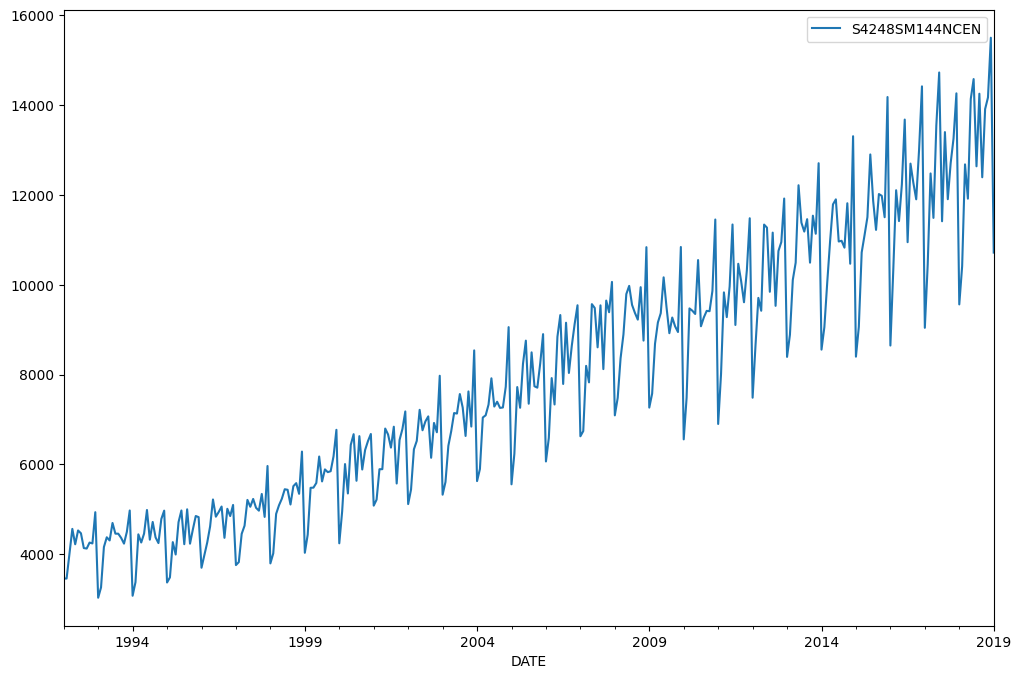

In [12]:
df.plot(figsize=(12,8))

In [46]:
df.columns = ['Sales']
df

,Sales
DATE,
1992-01-01,3459
1992-02-01,3458
1992-03-01,4002
1992-04-01,4564
1992-05-01,4221
...,...
2018-09-01,12396
2018-10-01,13914
2018-11-01,14174


In [47]:
df['Sales_LastMonth'] = df['Sales'].shift(+1)
df['Sales_2MonthsBack'] = df['Sales'].shift(+2)
df['Sales_3MonthBack'] = df['Sales'].shift(+3)

df

,Sales,Sales_LastMonth,Sales_2MonthsBack,Sales_3MonthBack
DATE,,,,
1992-01-01,3459,NaN,NaN,NaN
1992-02-01,3458,3459.0,NaN,NaN
1992-03-01,4002,3458.0,3459.0,NaN
1992-04-01,4564,4002.0,3458.0,3459.0
1992-05-01,4221,4564.0,4002.0,3458.0
...,...,...,...,...
2018-09-01,12396,14257.0,12640.0,14583.0
2018-10-01,13914,12396.0,14257.0,12640.0
2018-11-01,14174,13914.0,12396.0,14257.0


In [50]:
df.dropna(inplace=True)

In [51]:
df

,Sales,Sales_LastMonth,Sales_2MonthsBack,Sales_3MonthBack
DATE,,,,
1992-04-01,4564,4002.0,3458.0,3459.0
1992-05-01,4221,4564.0,4002.0,3458.0
1992-06-01,4529,4221.0,4564.0,4002.0
1992-07-01,4466,4529.0,4221.0,4564.0
1992-08-01,4137,4466.0,4529.0,4221.0
...,...,...,...,...
2018-09-01,12396,14257.0,12640.0,14583.0
2018-10-01,13914,12396.0,14257.0,12640.0
2018-11-01,14174,13914.0,12396.0,14257.0


In [61]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = df[['Sales_LastMonth', 'Sales_2MonthsBack', 'Sales_3MonthBack']].values
y = df[['Sales']].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.50, train_size=0.50, random_state=42)

lin_model = LinearRegression()
trained_lin_model = lin_model.fit(X_train, y_train)
lin_pred = trained_lin_model.predict(X_test)

lin_pred

array([[ 8862.31195547],
       [ 6091.31683172],
       [ 9630.53088151],
       [ 4818.15681004],
       [ 6485.02423918],
       [ 6021.92529581],
       [11472.62800546],
       [ 7927.30186896],
       [ 9148.38038036],
       [11146.37032808],
       [ 9780.40966996],
       [ 6008.90928817],
       [11803.50350353],
       [ 5038.90466107],
       [ 9298.13256296],
       [11186.74632014],
       [ 6823.45046275],
       [ 5605.83041998],
       [ 4378.21092189],
       [ 4626.77229643],
       [ 8085.82369607],
       [ 5089.46473138],
       [ 4634.92648268],
       [13023.11885464],
       [11049.01899448],
       [ 6374.38940448],
       [ 5252.97526779],
       [ 5538.19153818],
       [ 9671.73322329],
       [11359.007685  ],
       [ 5702.20200686],
       [ 9709.21346954],
       [ 5246.02071354],
       [ 9480.98740514],
       [10511.64427095],
       [ 8631.09510215],
       [12536.58110521],
       [ 4988.39216595],
       [ 6702.54172855],
       [ 8065.05566997],


In [70]:
y_test

array([[ 8037],
       [ 6741],
       [ 9225],
       [ 3031],
       [ 6678],
       [ 6337],
       [11462],
       [ 8757],
       [ 8014],
       [12683],
       [ 9375],
       [ 5849],
       [12022],
       [ 5483],
       [ 8123],
       [10828],
       [ 6924],
       [ 5583],
       [ 4460],
       [ 4126],
       [ 9162],
       [ 4850],
       [ 3983],
       [11907],
       [12481],
       [ 6545],
       [ 3758],
       [ 5515],
       [ 9553],
       [11186],
       [ 5894],
       [ 8923],
       [ 5231],
       [ 9272],
       [11922],
       [ 9156],
       [10950],
       [ 3370],
       [ 7045],
       [ 8902],
       [11416],
       [ 4554],
       [13261],
       [12396],
       [ 3699],
       [14730],
       [ 4435],
       [ 4952],
       [ 4457],
       [ 5435],
       [ 4243],
       [ 4240],
       [ 8195],
       [ 5107],
       [12107],
       [11506],
       [14583],
       [ 4466],
       [ 6901],
       [ 7180],
       [ 9967],
       [ 4635],
       [

In [69]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt

print("Mean absolute error is: ", mean_absolute_error(y_true=y_test.tolist(), y_pred=lin_pred.tolist()))
print("Root mean squared error is: ", sqrt(mean_squared_error(y_true=y_test.tolist(), y_pred=lin_pred.tolist())))

Mean absolute error is:  823.4460993774748
Root mean squared error is:  1105.7546865884142


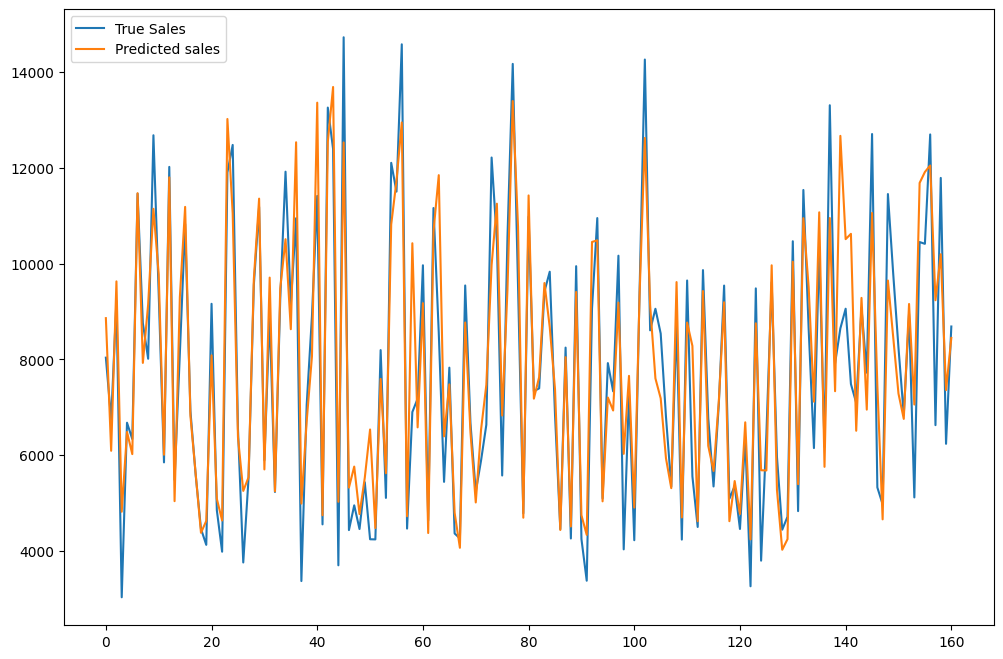

In [72]:
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12,8)
plt.plot(y_test, label = 'True Sales')
plt.plot(lin_pred, label='Predicted sales')
plt.legend(loc = 'upper left')
plt.show()